# Financial Social Search: full pipeline notebook

This notebook replaces the small staged notebooks with one end-to-end workflow. It prepares the corpus, explores the data, runs BM25 and TF-IDF retrieval, builds the social graph, computes social-search features, re-ranks results, evaluates the systems, and renders all visual outputs inside the notebook.

The visualization cells intentionally display figures inline instead of writing separate image files.


In [1]:
from __future__ import annotations

import io
import os
import sys
from collections import Counter
from itertools import combinations
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / 'results' / '.matplotlib'))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src import config
from src.data_collection import build_sample_dataset, load_stackexchange_dump
from src.evaluation import EVAL_QUERIES, _social_usefulness, _topical_label, evaluate_run
from src.preprocessing import clean_documents, tokenize
from src.retrieval import retrieve_candidates
from src.reranking import apply_social_reranking
from src.sentiment import financial_sentiment
from src.social_graph import build_social_graph, influence_table, resolve_searcher

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)

DEMO_QUERY = 'Should I pay off credit card debt before investing?'
INVESTING_QUERY = 'How should I start investing?'


def show_fig(fig, dpi: int = 150) -> None:
    """Render a matplotlib figure as an inline notebook image without saving a file."""
    buf = io.BytesIO()
    fig.tight_layout()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    display(Image(data=buf.getvalue()))


def truncate(value: object, max_chars: int = 90) -> str:
    text = str(value or '').replace('\n', ' ').strip()
    return text if len(text) <= max_chars else text[: max_chars - 3].rstrip() + '...'


## 1. Prepare the corpus

The notebook uses the real Money Stack Exchange dump if `data/raw/Posts.xml` exists. Otherwise it builds the deterministic offline sample corpus in memory. No processed CSV or PNG output is required for the notebook run.


In [2]:
paths = config.StackExchangePaths()
if paths.posts_xml.exists():
    raw_docs = load_stackexchange_dump(paths)
    data_source = 'Money Stack Exchange dump in data/raw/'
else:
    raw_docs = build_sample_dataset()
    data_source = 'deterministic offline sample corpus'

docs = clean_documents(raw_docs)

if 'aspect' not in docs.columns:
    def infer_aspect(row: pd.Series) -> str:
        text = f"{row.get('tags', '')} {row.get('title', '')} {row.get('combined_text', '')}".lower()
        return next((aspect for aspect in config.FINANCIAL_ASPECTS if aspect in text), 'general')
    docs['aspect'] = docs.apply(infer_aspect, axis=1)

display(Markdown(f'**Data source:** {data_source}'))
display(pd.DataFrame([{
    'answer_documents': len(docs),
    'unique_questions': docs['question_id'].nunique() if 'question_id' in docs else None,
    'unique_authors': docs['owner_user_id'].nunique() if 'owner_user_id' in docs else None,
    'columns': len(docs.columns),
}]))

preview_cols = [
    'doc_id', 'title', 'tags', 'aspect', 'owner_user_id', 'answer_score',
    'accepted_answer', 'comment_count', 'question_view_count', 'author_reputation',
]
display(docs[[c for c in preview_cols if c in docs.columns]].head(8))


**Data source:** deterministic offline sample corpus

,answer_documents,unique_questions,unique_authors,columns
0,46,22,11,23


,doc_id,title,tags,aspect,owner_user_id,answer_score,accepted_answer,comment_count,question_view_count,author_reputation
0,sample-a1001,Should I pay off credit card debt before investing?,credit-card debt investing,debt,303,37,False,1,12747,35000
1,sample-a1002,Should I pay off credit card debt before investing?,credit-card debt investing,debt,309,15,False,1,12747,9000
2,sample-a1003,Should I pay off credit card debt before investing?,credit-card debt investing,debt,302,43,True,8,12747,38000
3,sample-a1004,How do I get out of credit card debt fastest?,credit-card debt budgeting,debt,302,48,True,0,11249,38000
4,sample-a1005,How do I get out of credit card debt fastest?,credit-card debt budgeting,debt,303,24,False,8,11249,35000
5,sample-a1006,How much emergency fund should I keep?,emergency-fund saving budgeting,saving,303,23,False,8,32405,35000
6,sample-a1007,How much emergency fund should I keep?,emergency-fund saving budgeting,saving,302,47,True,7,32405,38000
7,sample-a1008,Where should I keep my emergency savings?,saving emergency-fund risk,saving,305,21,False,3,24280,19000


## 2. Explore useful corpus signals

These summaries show the social evidence available to the ranker: author reputation, answer scores, accepted answers, comments, views, freshness, tags, and financial aspects.


In [3]:
numeric_cols = [
    'answer_score', 'comment_count', 'question_view_count', 'answer_count',
    'author_reputation', 'age_days',
]
summary = docs[[c for c in numeric_cols if c in docs.columns]].describe().T
summary = summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)
display(summary)

aspect_summary = (
    docs.groupby('aspect')
    .agg(
        documents=('doc_id', 'count'),
        avg_answer_score=('answer_score', 'mean'),
        accepted_rate=('accepted_answer', 'mean'),
        avg_reputation=('author_reputation', 'mean'),
    )
    .sort_values('documents', ascending=False)
    .round(3)
)
display(aspect_summary)

tag_counts = Counter()
for tags in docs['tags'].fillna(''):
    tag_counts.update(tokenize(tags))
display(pd.DataFrame(tag_counts.most_common(15), columns=['tag', 'documents']))


,count,mean,std,min,25%,50%,75%,max
answer_score,46.0,37.46,11.64,15.0,26.25,38.0,47.00,58.0
comment_count,46.0,4.35,2.94,0.0,2.00,3.5,7.00,9.0
question_view_count,46.0,31202.67,13468.78,9830.0,18947.00,33117.0,42853.00,49670.0
answer_count,46.0,2.13,0.34,2.0,2.00,2.0,2.00,3.0
author_reputation,46.0,32106.52,11536.12,900.0,25250.00,38000.0,41000.00,41000.0
age_days,46.0,760.70,415.11,201.0,474.00,658.0,977.75,1601.0


,documents,avg_answer_score,accepted_rate,avg_reputation
aspect,,,,
investing,11,37.455,0.455,37000.000
saving,8,36.375,0.500,27000.000
mortgage,6,41.167,0.500,29816.667
debt,5,33.400,0.400,31000.000
credit,4,39.250,0.500,38000.000
retirement,4,37.250,0.500,27250.000
risk,4,37.250,0.500,35000.000
tax,4,37.750,0.500,29750.000


,tag,documents
0,investing,24
1,saving,10
2,credit-card,9
3,debt,9
4,emergency-fund,8
5,risk,8
6,etf,7
7,budgeting,6
8,mortgage,6
9,tax,6


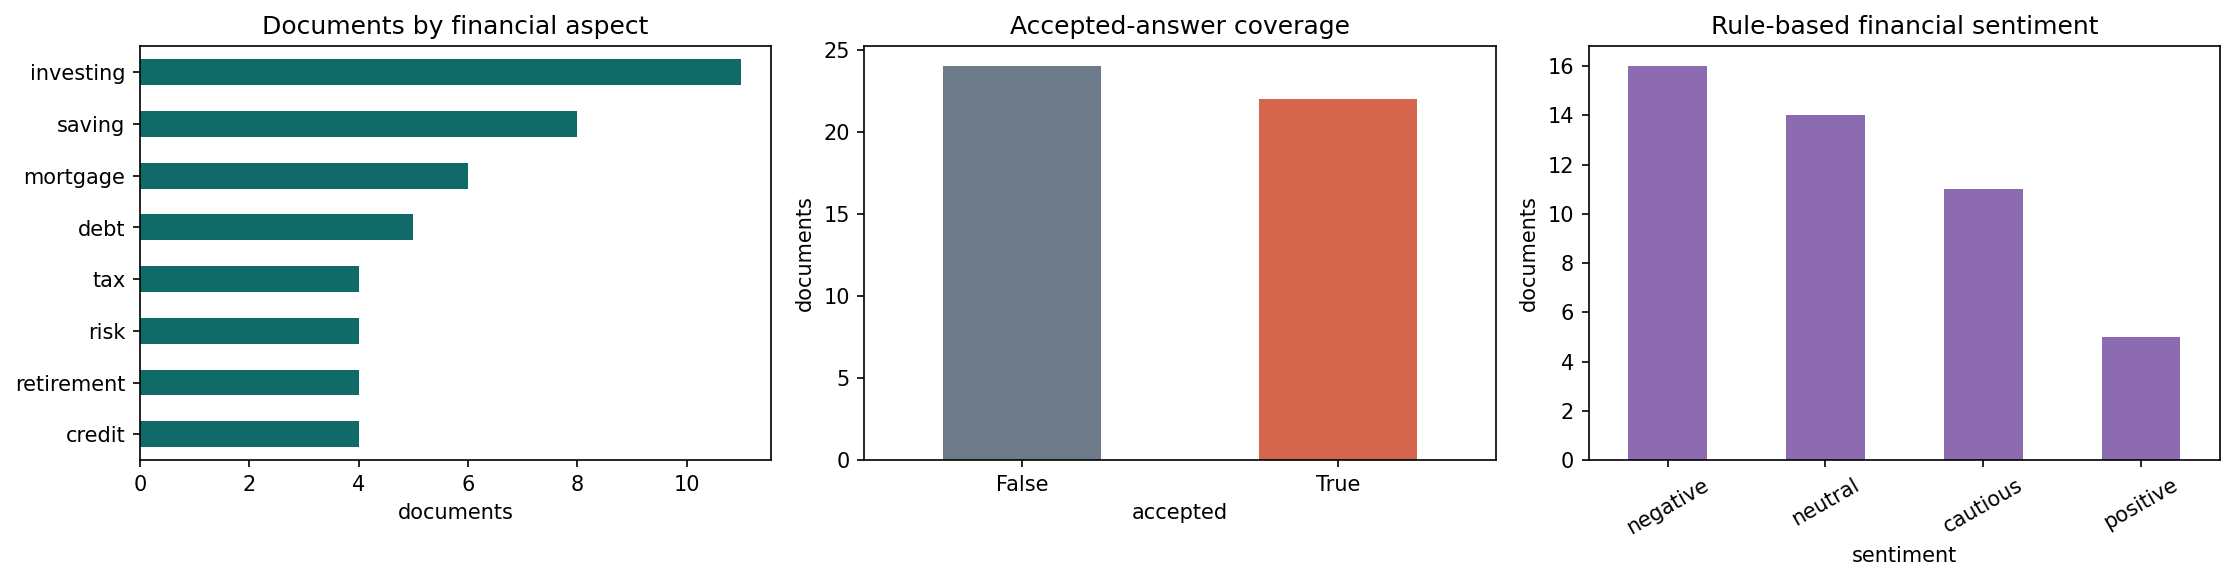

In [4]:
sentiment_by_doc = docs.apply(
    lambda row: financial_sentiment(f"{row.get('tags', '')} {row.get('combined_text', '')}"),
    axis=1,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
docs['aspect'].value_counts().sort_values().plot(kind='barh', ax=axes[0], color='#106b68')
axes[0].set_title('Documents by financial aspect')
axes[0].set_xlabel('documents')
axes[0].set_ylabel('')

docs['accepted_answer'].astype(bool).value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['#6c7a89', '#d6654e'])
axes[1].set_title('Accepted-answer coverage')
axes[1].set_xlabel('accepted')
axes[1].set_ylabel('documents')
axes[1].tick_params(axis='x', rotation=0)

sentiment_by_doc.value_counts().plot(kind='bar', ax=axes[2], color='#8c6bb1')
axes[2].set_title('Rule-based financial sentiment')
axes[2].set_xlabel('sentiment')
axes[2].set_ylabel('documents')
axes[2].tick_params(axis='x', rotation=30)

show_fig(fig)


## 3. Aspect-level financial sentiment

This is the inline notebook version of `aspect_sentiment()` from `src/visualization.py`. It crosses each document's financial aspect with the rule-based sentiment label and renders the stacked bar chart inside this notebook instead of saving `aspect_sentiment_chart.png`.


sentiment,negative,positive,neutral,cautious
aspect,,,,
debt,5,0,0,0
saving,2,2,3,1
mortgage,2,0,2,2
tax,0,0,0,4
investing,4,3,4,0
risk,1,0,0,3
retirement,1,0,2,1
credit,1,0,3,0


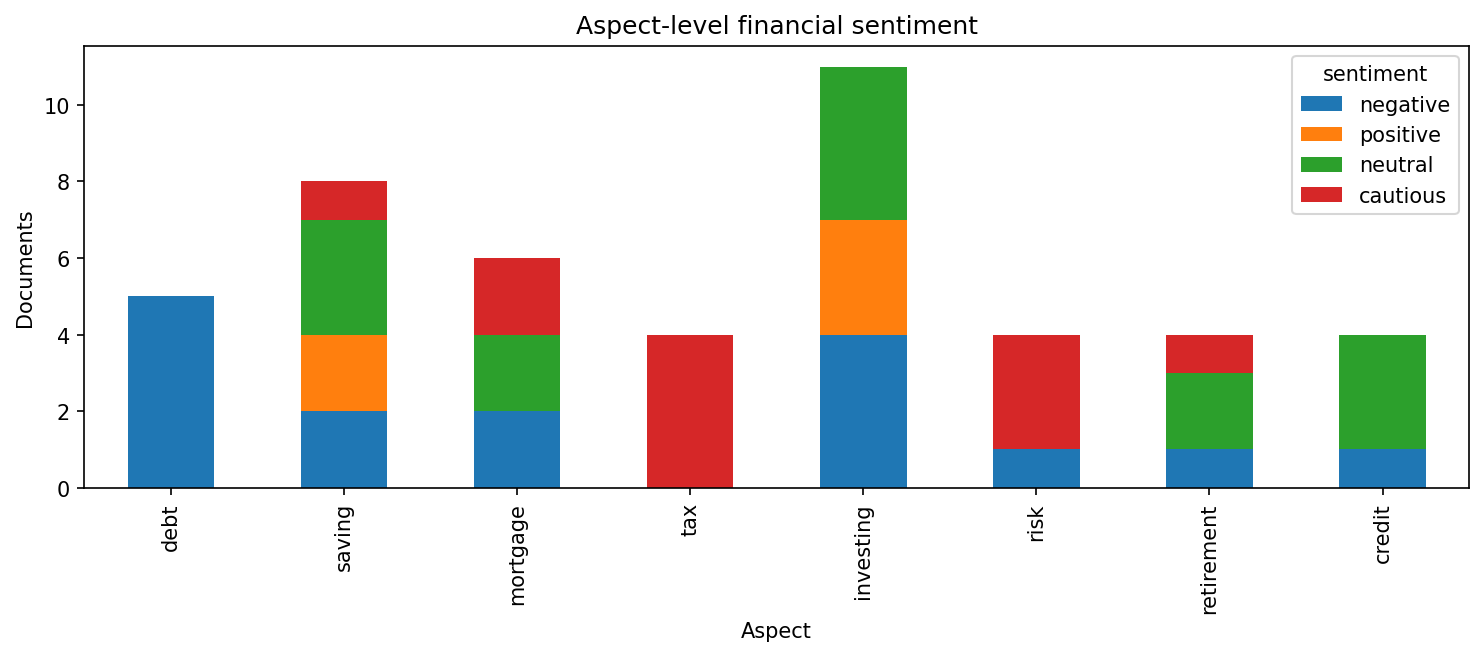

In [5]:
aspect_sentiment_rows = []
for _, row in docs.iterrows():
    text = f"{row.get('tags', '')} {row.get('combined_text', '')}"
    aspect = row.get('aspect') or next((a for a in config.FINANCIAL_ASPECTS if a in text), 'general')
    aspect_sentiment_rows.append({'aspect': aspect, 'sentiment': financial_sentiment(text)})

aspect_sentiment_counts = (
    pd.DataFrame(aspect_sentiment_rows)
    .value_counts(['aspect', 'sentiment'])
    .unstack(fill_value=0)
)

aspect_order = list(dict.fromkeys(row['aspect'] for row in aspect_sentiment_rows))
sentiment_order = ['negative', 'positive', 'neutral', 'cautious']
aspect_sentiment_counts = aspect_sentiment_counts.reindex(index=aspect_order, fill_value=0)
aspect_sentiment_counts = aspect_sentiment_counts.reindex(columns=sentiment_order, fill_value=0)

display(aspect_sentiment_counts)

fig, ax = plt.subplots(figsize=(10, 4.5))
aspect_sentiment_counts.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_title('Aspect-level financial sentiment')
ax.set_xlabel('Aspect')
ax.set_ylabel('Documents')
ax.tick_params(axis='x', rotation=90)
ax.legend(title='sentiment')
show_fig(fig)


## 4. Baseline retrieval

BM25 and TF-IDF retrieve candidates from `combined_text`, which joins title, question text, answer text, and tags. These candidate sets are the topical base that the social layer re-ranks.


,method,rank,doc_id,title,tags,retrieval_score,answer_score,accepted_answer
0,BM25,1,sample-a1001,Should I pay off credit card debt before investing?,credit-card debt investing,21.0024,37,False
1,BM25,2,sample-a1002,Should I pay off credit card debt before investing?,credit-card debt investing,18.8781,15,False
2,BM25,3,sample-a1003,Should I pay off credit card debt before investing?,credit-card debt investing,18.6593,43,True
3,BM25,4,sample-a1004,How do I get out of credit card debt fastest?,credit-card debt budgeting,7.3504,48,True
4,BM25,5,sample-a1005,How do I get out of credit card debt fastest?,credit-card debt budgeting,7.2903,24,False
5,BM25,6,sample-a1044,Should I pay extra on my mortgage or invest?,mortgage investing debt,5.8602,45,True
6,BM25,7,sample-a1034,How can I improve my credit score?,credit-score credit-card debt,5.8205,31,False
7,BM25,8,sample-a1033,How can I improve my credit score?,credit-score credit-card debt,5.7420,52,True
8,BM25,9,sample-a1043,Should I pay extra on my mortgage or invest?,mortgage investing debt,5.4716,38,False
9,BM25,10,sample-a1031,When should I prioritise retirement contributions?,retirement investing saving,5.4382,49,True


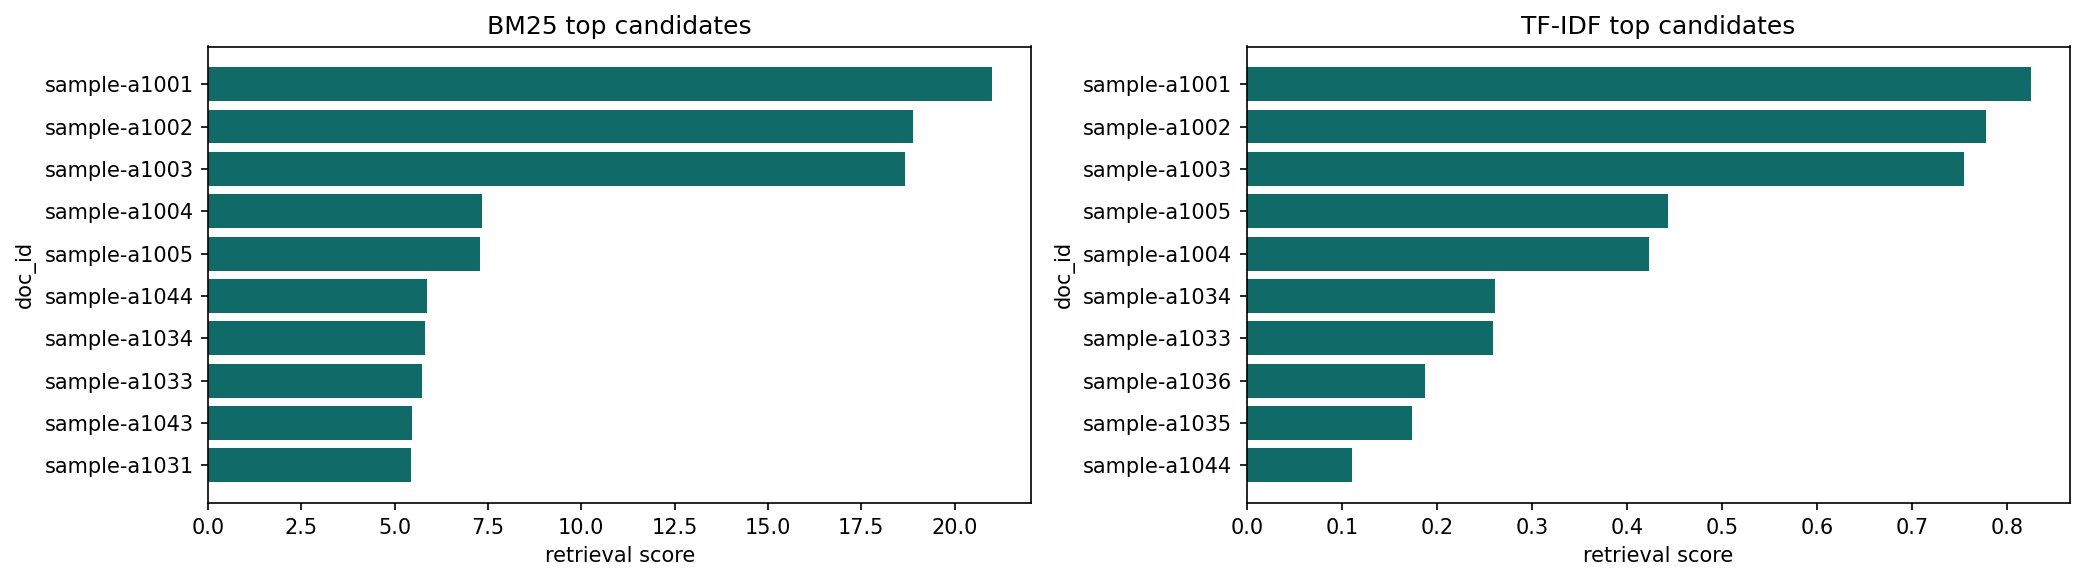

In [6]:
bm25_top = retrieve_candidates(docs, DEMO_QUERY, method='bm25', candidates=10)
tfidf_top = retrieve_candidates(docs, DEMO_QUERY, method='tfidf', candidates=10)

baseline_view = pd.concat([
    bm25_top.assign(method='BM25'),
    tfidf_top.assign(method='TF-IDF'),
], ignore_index=True)

show_cols = ['method', 'rank', 'doc_id', 'title', 'tags', 'retrieval_score', 'answer_score', 'accepted_answer']
display(baseline_view[[c for c in show_cols if c in baseline_view.columns]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=False)
for ax, frame, title in [(axes[0], bm25_top, 'BM25 top candidates'), (axes[1], tfidf_top, 'TF-IDF top candidates')]:
    ax.barh(frame['doc_id'].astype(str), frame['retrieval_score'], color='#106b68')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('retrieval score')
    ax.set_ylabel('doc_id')
show_fig(fig)


## 5. Build the social graph

The social graph is a directed NetworkX graph. Edges represent user interactions: askers point to answer authors, and commenters point to answer authors. PageRank gives author influence; greedy modularity gives communities.


,users,interaction_edges,communities,most_influential_user
0,33,62,6,301


,user_id,influence_pagerank_norm,community,in_degree,expertise_tags
0,301,1.0000,1,15,advisor beginner buy capital-gains credit-card
1,302,0.6073,2,11,advisor budgeting capital-gains credit-card debt
2,303,0.6058,0,10,budgeting capital-gains credit-card credit-score debt
3,305,0.3864,3,6,bonds budgeting emergency-fund risk saving
4,304,0.2588,1,5,beginner etf fees investing
5,307,0.1928,2,4,investing ira retirement roth saving
6,311,0.1312,5,3,capital-gains investing tax
7,310,0.1312,3,3,bonds emergency-fund saving treasury
8,306,0.1070,4,3,buy housing mortgage rent
9,314,0.0318,1,1,interest-rate mortgage refinance


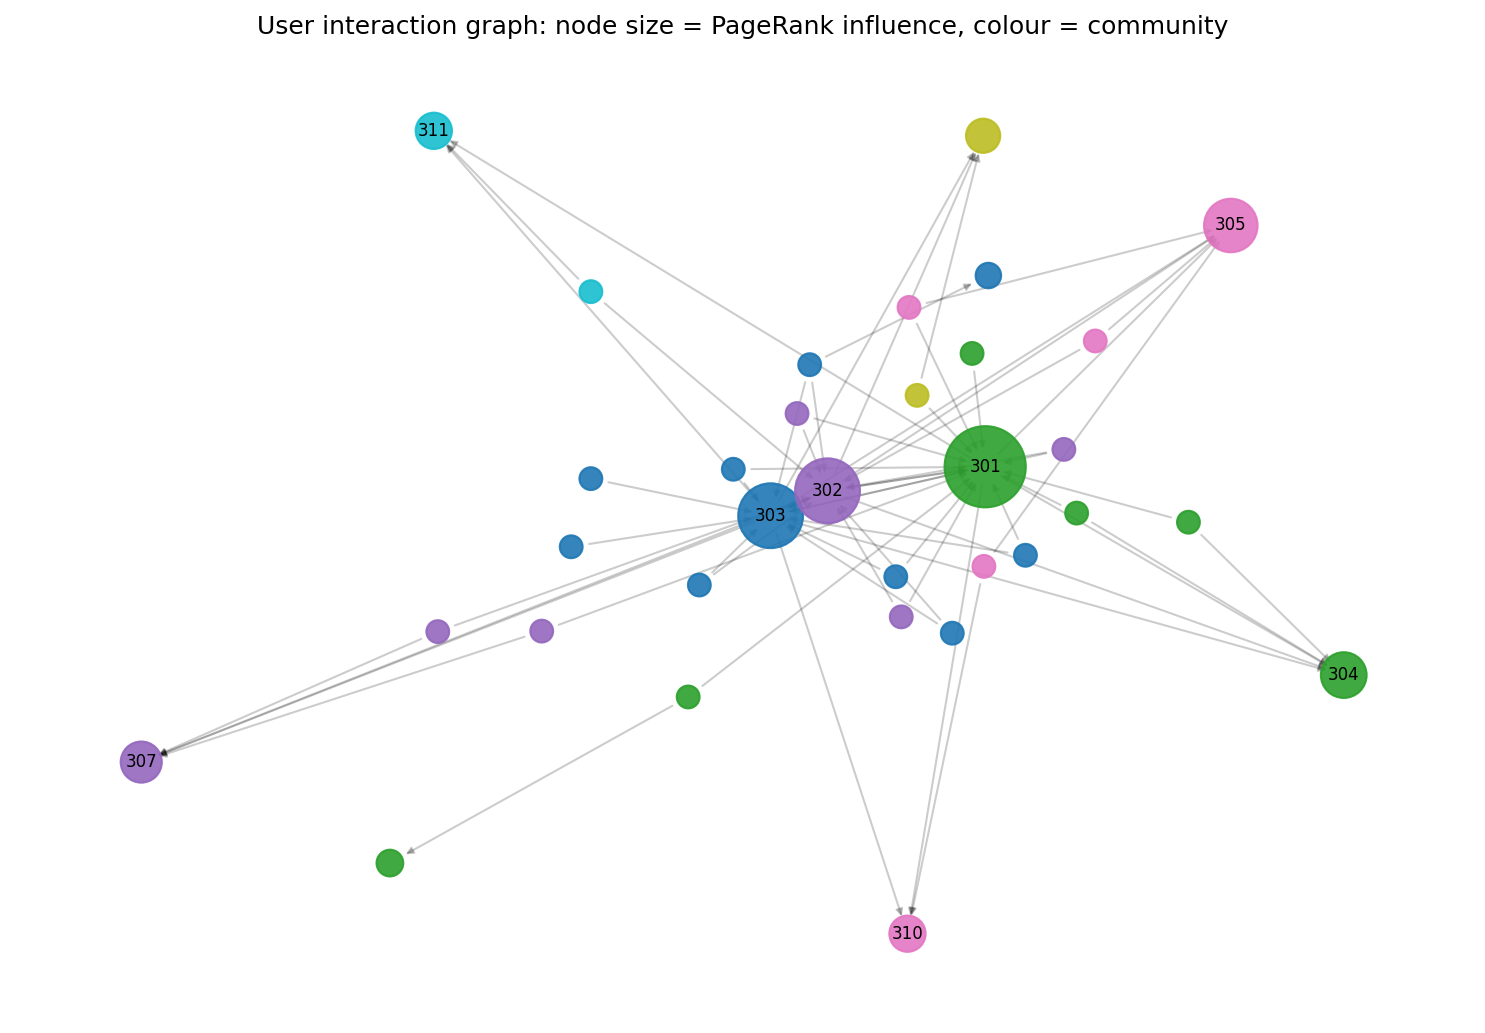

In [7]:
graph_ctx = build_social_graph(docs)

graph_stats = pd.DataFrame([{
    'users': graph_ctx.graph.number_of_nodes(),
    'interaction_edges': graph_ctx.graph.number_of_edges(),
    'communities': len(set(graph_ctx.community.values())),
    'most_influential_user': max(graph_ctx.influence, key=graph_ctx.influence.get) if graph_ctx.influence else None,
}])
display(graph_stats)
display(influence_table(graph_ctx, top_n=12))

fig, ax = plt.subplots(figsize=(10, 7))
g = graph_ctx.graph
if g.number_of_nodes():
    pos = nx.spring_layout(g, seed=11, k=0.6)
    sizes = [120 + 1400 * graph_ctx.influence.get(node, 0.0) for node in g.nodes]
    colors = [graph_ctx.community.get(node, 0) for node in g.nodes]
    nx.draw_networkx_edges(g, pos, ax=ax, alpha=0.2, arrows=True, arrowsize=7)
    nx.draw_networkx_nodes(g, pos, ax=ax, node_size=sizes, node_color=colors, cmap='tab10', alpha=0.9)
    top_labels = dict(sorted(graph_ctx.influence.items(), key=lambda kv: kv[1], reverse=True)[:8])
    nx.draw_networkx_labels(g, pos, labels={n: str(n) for n in top_labels}, ax=ax, font_size=8)
ax.set_title('User interaction graph: node size = PageRank influence, colour = community')
ax.axis('off')
show_fig(fig)


## 6. Social features and re-ranking

The re-ranker computes normalized topical, community, credibility, influence, engagement, freshness, tag-match, and sentiment-alignment scores. The final score is a transparent weighted sum.


In [8]:
candidates = retrieve_candidates(docs, DEMO_QUERY, method='bm25', candidates=100)
social_ranked = apply_social_reranking(candidates, DEMO_QUERY, graph_ctx=graph_ctx).head(10)

rank_cols = [
    'rank', 'doc_id', 'title', 'tags', 'final_score', 'topical_score', 'community_score',
    'credibility_score', 'author_influence_score', 'engagement_score', 'freshness_score',
    'tag_match_score', 'sentiment_alignment_score',
]
display(social_ranked[[c for c in rank_cols if c in social_ranked.columns]].round(4))

display(pd.DataFrame(
    [{'feature': feature, 'weight': weight} for feature, weight in config.DEFAULT_SOCIAL_WEIGHTS.items()]
))


,rank,doc_id,title,tags,final_score,topical_score,community_score,credibility_score,author_influence_score,engagement_score,freshness_score,tag_match_score,sentiment_alignment_score
0,1,sample-a1003,Should I pay off credit card debt before investing?,credit-card debt investing,0.8109,0.8884,0.8727,0.9801,0.6073,0.7717,0.5224,0.2222,0.8
1,2,sample-a1001,Should I pay off credit card debt before investing?,credit-card debt investing,0.7700,1.0000,0.3753,0.9586,0.6058,0.3161,0.5664,0.2222,0.8
2,3,sample-a1002,Should I pay off credit card debt before investing?,credit-card debt investing,0.5755,0.8989,0.0000,0.6028,0.0212,0.3161,0.1262,0.2222,0.8
3,4,sample-a1033,How can I improve my credit score?,credit-score credit-card debt,0.5190,0.2734,0.9535,1.0000,1.0000,0.5137,0.4605,0.1000,0.8
4,5,sample-a1044,Should I pay extra on my mortgage or invest?,mortgage investing debt,0.5105,0.2790,0.8920,1.0000,1.0000,0.7087,0.1492,0.2222,0.7
5,6,sample-a1031,When should I prioritise retirement contributions?,retirement investing saving,0.4983,0.2589,0.9282,0.9801,0.6073,0.6095,0.7277,0.1000,0.8
6,7,sample-a1004,How do I get out of credit card debt fastest?,credit-card debt budgeting,0.4891,0.3500,0.9194,0.9801,0.6073,0.0000,0.3891,0.1000,0.8
7,8,sample-a1005,How do I get out of credit card debt fastest?,credit-card debt budgeting,0.4427,0.3471,0.1936,0.9586,0.6058,0.6656,0.7593,0.1000,0.8
8,9,sample-a1016,What records do I need for investment taxes?,tax investing capital-gains,0.4359,0.1250,0.9695,0.9801,0.6073,0.7279,0.4605,0.1000,0.9
9,10,sample-a1013,Should I refinance my mortgage?,mortgage refinance interest-rate,0.4217,0.0525,0.9850,1.0000,1.0000,0.6126,0.6157,0.0000,0.8


,feature,weight
0,topical_score,0.50
1,community_score,0.14
2,credibility_score,0.08
3,author_influence_score,0.07
4,engagement_score,0.06
5,freshness_score,0.05
6,tag_match_score,0.05
7,sentiment_alignment_score,0.05


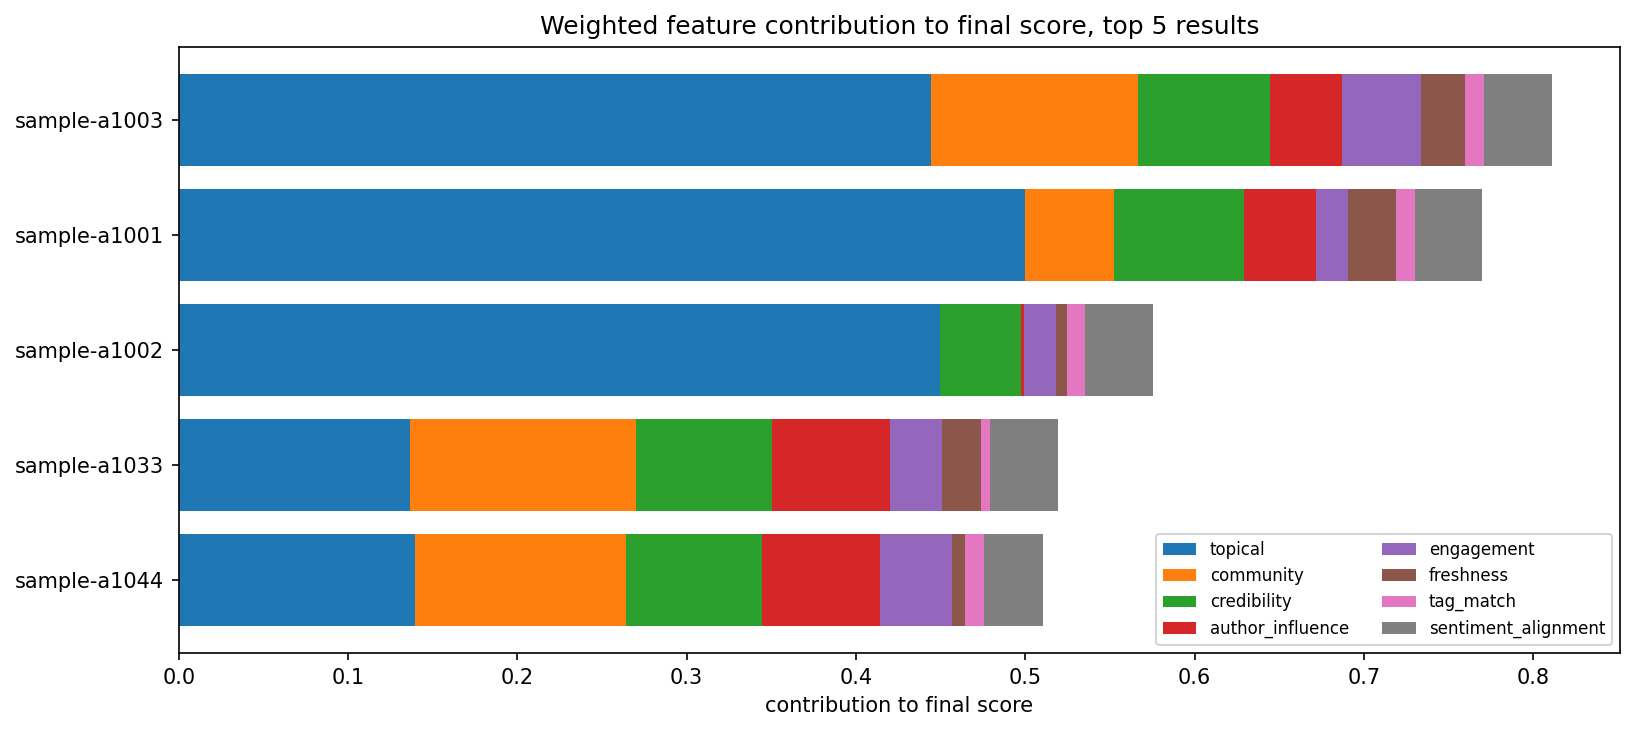

In [9]:
features = [
    'topical_score', 'community_score', 'credibility_score', 'author_influence_score',
    'engagement_score', 'freshness_score', 'tag_match_score', 'sentiment_alignment_score',
]
contrib = social_ranked.head(5).copy()

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(contrib))
for feature in features:
    values = contrib[feature].fillna(0).to_numpy() * config.DEFAULT_SOCIAL_WEIGHTS.get(feature, 0.0)
    ax.barh(contrib['doc_id'].astype(str), values, left=bottom, label=feature.replace('_score', ''))
    bottom = bottom + values
ax.invert_yaxis()
ax.set_title('Weighted feature contribution to final score, top 5 results')
ax.set_xlabel('contribution to final score')
ax.legend(fontsize=8, ncols=2)
show_fig(fig)


,doc_id,title,bm25_rank,social_rank,movement
0,sample-a1003,Should I pay off credit card debt before investing?,3.0,1,2
1,sample-a1001,Should I pay off credit card debt before investing?,1.0,2,-1
2,sample-a1002,Should I pay off credit card debt before investing?,2.0,3,-1
3,sample-a1033,How can I improve my credit score?,8.0,4,4
4,sample-a1044,Should I pay extra on my mortgage or invest?,6.0,5,1
5,sample-a1031,When should I prioritise retirement contributions?,10.0,6,4
6,sample-a1004,How do I get out of credit card debt fastest?,4.0,7,-3
7,sample-a1005,How do I get out of credit card debt fastest?,5.0,8,-3
8,sample-a1016,What records do I need for investment taxes?,NaN,9,entered top 10
9,sample-a1013,Should I refinance my mortgage?,NaN,10,entered top 10


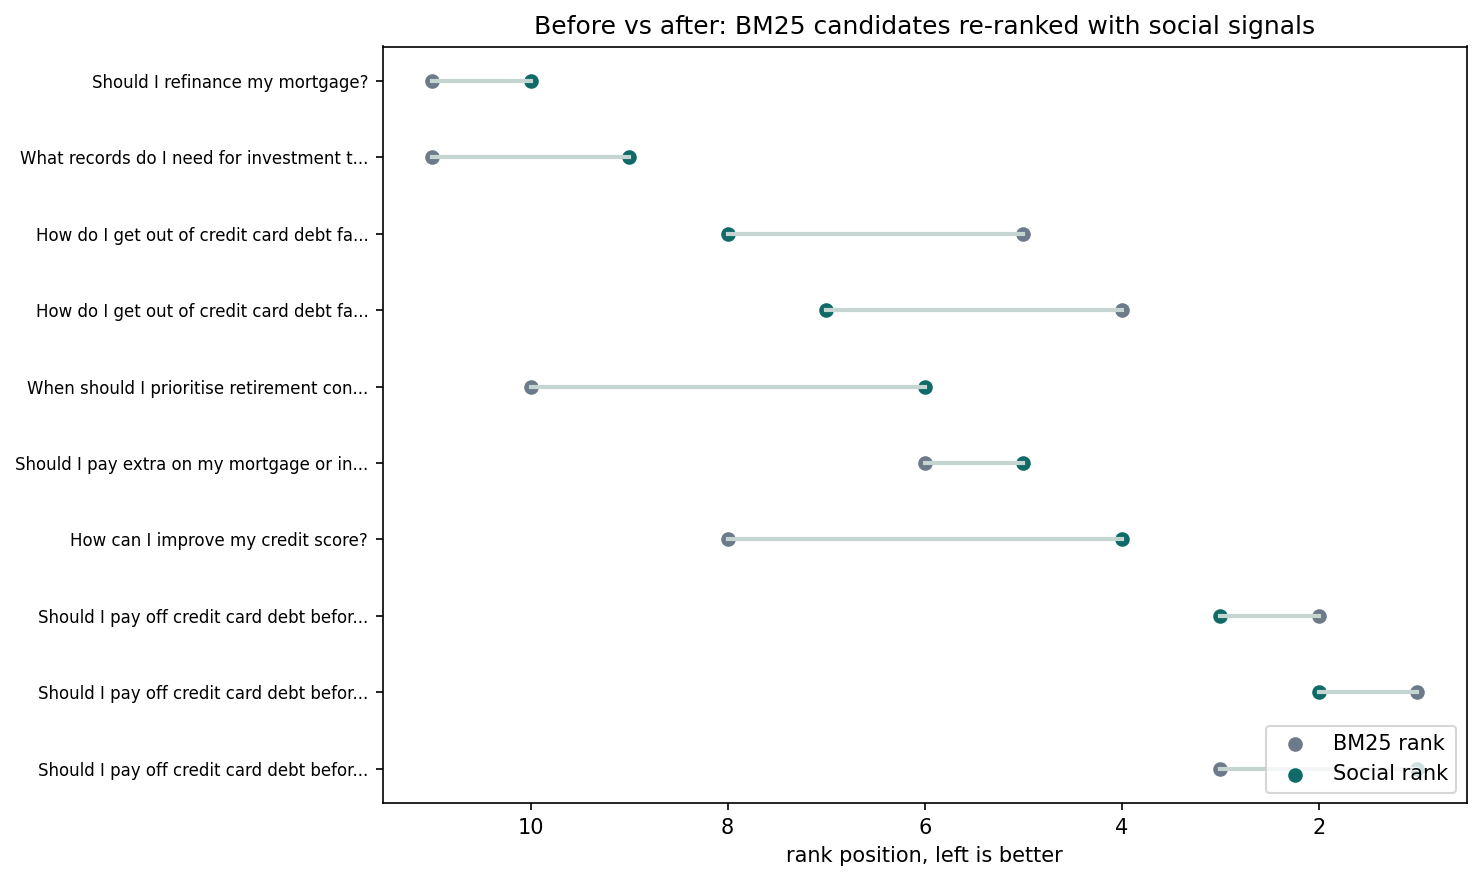

In [10]:
bm25_rank_by_doc = dict(zip(bm25_top['doc_id'].astype(str), bm25_top['rank']))
plot_rows = social_ranked[['doc_id', 'title', 'rank']].copy()
plot_rows['bm25_rank'] = plot_rows['doc_id'].astype(str).map(bm25_rank_by_doc).fillna(11)
plot_rows = plot_rows.rename(columns={'rank': 'social_rank'}).head(10)

movement_rows = []
for _, row in plot_rows.iterrows():
    before = int(row['bm25_rank']) if row['bm25_rank'] != 11 else None
    after = int(row['social_rank'])
    movement_rows.append({
        'doc_id': row['doc_id'],
        'title': truncate(row['title'], 70),
        'bm25_rank': before,
        'social_rank': after,
        'movement': 'entered top 10' if before is None else before - after,
    })
display(pd.DataFrame(movement_rows))

fig, ax = plt.subplots(figsize=(10, 6))
for y, (_, row) in enumerate(plot_rows.iterrows()):
    ax.plot([row['bm25_rank'], row['social_rank']], [y, y], color='#c5d5d1', linewidth=2)
    ax.scatter(row['bm25_rank'], y, color='#6c7a89', label='BM25 rank' if y == 0 else '')
    ax.scatter(row['social_rank'], y, color='#106b68', label='Social rank' if y == 0 else '')
ax.set_yticks(range(len(plot_rows)))
ax.set_yticklabels([truncate(title, 42) for title in plot_rows['title']], fontsize=8)
ax.set_xlim(11.5, 0.5)
ax.set_xlabel('rank position, left is better')
ax.set_title('Before vs after: BM25 candidates re-ranked with social signals')
ax.legend(loc='lower right')
show_fig(fig)


## 7. Searcher-aware personalization

Supplying a searcher identity adds social proximity and community affinity. The same query can rank differently for different searchers.


,searcher,intent_profile,followed_authors,followed_communities,interest_tags
0,beginner_saver,beginner,"[301, 302, 303]","[0, 1, 2]","[budgeting, credit-score, debt, emergency-fund, saving]"
1,active_investor,advanced_investor,"[301, 302, 307]","[1, 2]","[etf, investing, retirement, stocks, tax]"
2,cautious_planner,risk_sensitive,"[301, 302, 303]","[0, 1, 2]","[fraud, mortgage, risk, scam, tax]"


,doc_id,title,rank_no_searcher,rank_beginner_saver,rank_active_investor,rank_cautious_planner
0,sample-a1042,How do I start investing with little money?,1.0,1.0,1.0,1.0
1,sample-a1041,How do I start investing with little money?,2.0,3.0,2.0,2.0
2,sample-a1014,How are capital gains taxed?,3.0,4.0,3.0,3.0
3,sample-a1007,How much emergency fund should I keep?,4.0,2.0,NaN,5.0
4,sample-a1044,Should I pay extra on my mortgage or invest?,5.0,6.0,NaN,4.0
5,sample-a1003,Should I pay off credit card debt before investing?,6.0,NaN,NaN,NaN
6,sample-a1046,How do I budget on an irregular income?,NaN,5.0,NaN,NaN
7,sample-a1018,Should I invest in ETFs or individual stocks?,NaN,NaN,4.0,NaN
8,sample-a1020,Should I invest in ETFs or individual stocks?,NaN,NaN,5.0,NaN
9,sample-a1031,When should I prioritise retirement contributions?,NaN,NaN,6.0,NaN


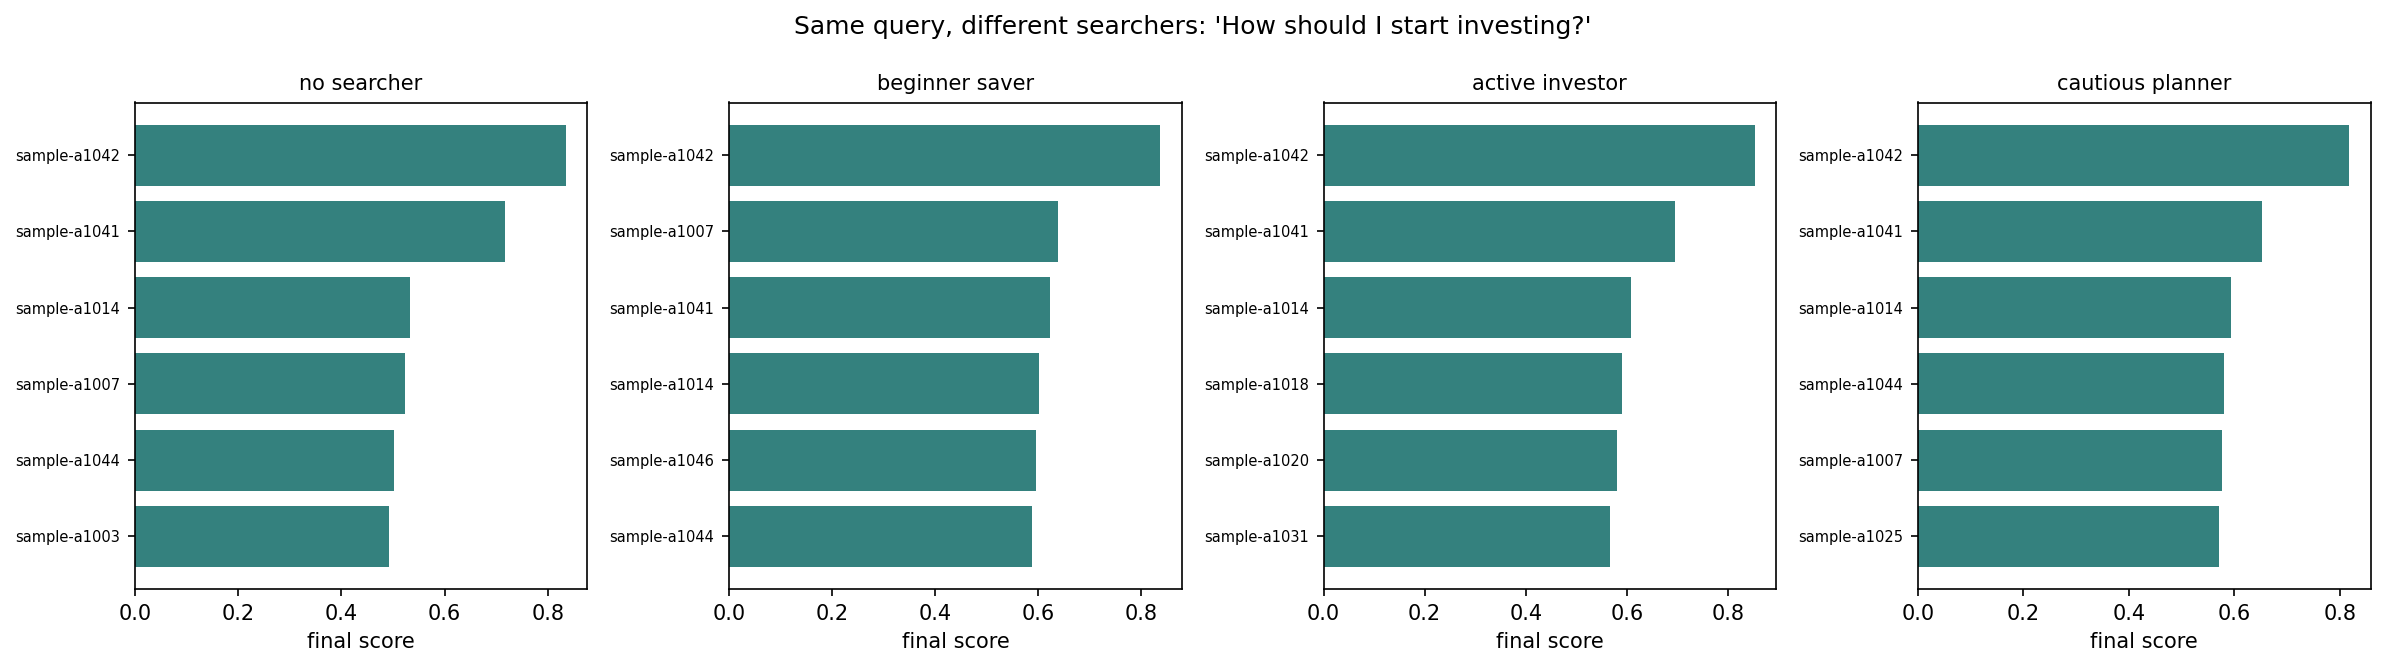

In [11]:
personal_candidates = retrieve_candidates(docs, INVESTING_QUERY, method='bm25', candidates=100)
panels = {'no_searcher': apply_social_reranking(personal_candidates, INVESTING_QUERY, graph_ctx=graph_ctx).head(6)}
searcher_details = []
for name in ['beginner_saver', 'active_investor', 'cautious_planner']:
    searcher = resolve_searcher(graph_ctx, config.SEARCHER_PROFILES[name], name)
    panels[name] = apply_social_reranking(personal_candidates, INVESTING_QUERY, graph_ctx=graph_ctx, searcher=searcher).head(6)
    searcher_details.append({
        'searcher': name,
        'intent_profile': searcher.intent_profile,
        'followed_authors': sorted(searcher.followed_authors),
        'followed_communities': sorted(searcher.followed_communities),
        'interest_tags': sorted(searcher.interest_tags),
    })

display(pd.DataFrame(searcher_details))

all_doc_ids = list(dict.fromkeys(doc_id for frame in panels.values() for doc_id in frame['doc_id'].astype(str)))
comparison = []
for doc_id in all_doc_ids:
    row = {'doc_id': doc_id}
    title = docs.loc[docs['doc_id'].astype(str) == doc_id, 'title']
    row['title'] = truncate(title.iloc[0], 70) if len(title) else ''
    for name, frame in panels.items():
        match = frame[frame['doc_id'].astype(str) == doc_id]
        row[f'rank_{name}'] = int(match['rank'].iloc[0]) if len(match) else None
    comparison.append(row)
display(pd.DataFrame(comparison))

fig, axes = plt.subplots(1, len(panels), figsize=(16, 4.5), sharey=False)
for ax, (name, frame) in zip(axes, panels.items()):
    ax.barh(frame['doc_id'].astype(str), frame['final_score'], color='#106b68', alpha=0.85)
    ax.invert_yaxis()
    ax.set_title(name.replace('_', ' '), fontsize=10)
    ax.set_xlabel('final score')
    ax.tick_params(axis='y', labelsize=7)
fig.suptitle(f"Same query, different searchers: {INVESTING_QUERY!r}", fontsize=12)
show_fig(fig)


## 8. Topic network

The tag co-occurrence graph shows which financial concepts appear together in the corpus.


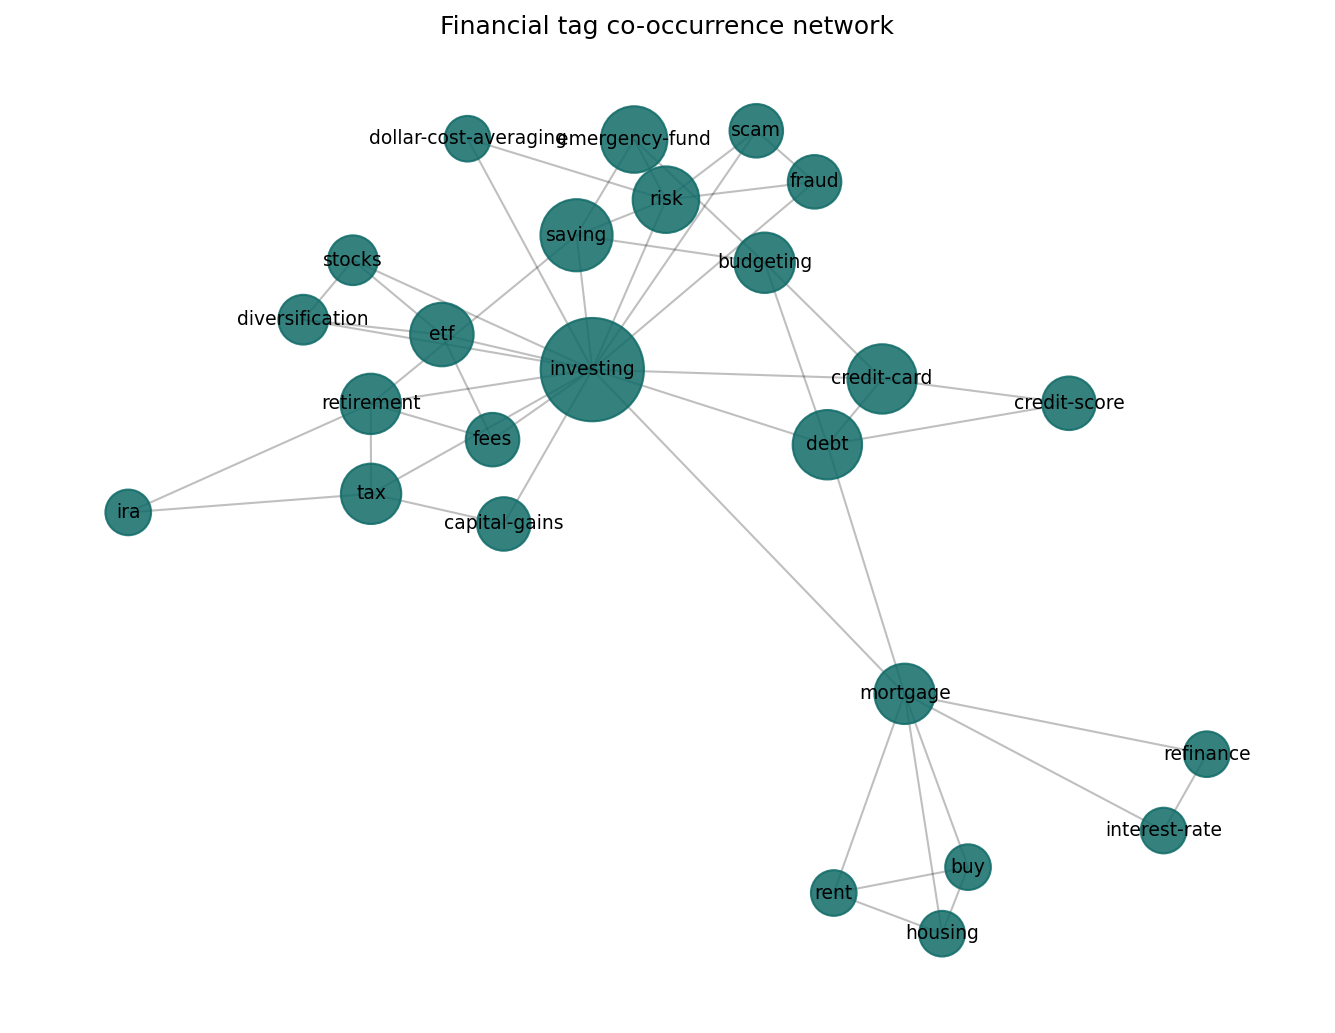

In [12]:
tag_counts = Counter()
edge_counts = Counter()
for tags in docs['tags'].fillna(''):
    unique_tags = sorted(set(tokenize(tags)))
    tag_counts.update(unique_tags)
    edge_counts.update(combinations(unique_tags, 2))

tag_graph = nx.Graph()
for tag, count in tag_counts.most_common(25):
    tag_graph.add_node(tag, size=count)
for (a, b), count in edge_counts.items():
    if a in tag_graph and b in tag_graph:
        tag_graph.add_edge(a, b, weight=count)

fig, ax = plt.subplots(figsize=(9, 7))
if tag_graph.number_of_nodes():
    pos = nx.spring_layout(tag_graph, seed=7)
    nx.draw_networkx_edges(tag_graph, pos, ax=ax, alpha=0.25)
    nx.draw_networkx_nodes(
        tag_graph,
        pos,
        ax=ax,
        node_size=[300 + tag_graph.nodes[n]['size'] * 90 for n in tag_graph],
        node_color='#106b68',
        alpha=0.85,
    )
    nx.draw_networkx_labels(tag_graph, pos, ax=ax, font_size=9)
ax.set_title('Financial tag co-occurrence network')
ax.axis('off')
show_fig(fig)


## 9. In-memory evaluation and ablation

This section mirrors the project evaluation, but keeps the run data in memory for notebook display. It builds a TREC-style judged pool from BM25, TF-IDF, and BM25+Social top results, then evaluates against topical, social-usefulness, and combined gold labels.


In [13]:
def build_judgments_in_memory(docs: pd.DataFrame, graph_ctx, top_k: int = 10) -> pd.DataFrame:
    query_rows = [
        {'query_id': f'Q{i:02d}', 'query': query, 'aspect': aspect}
        for i, (query, aspect) in enumerate(EVAL_QUERIES, start=1)
    ]
    records = []
    for qrow in query_rows:
        query = qrow['query']
        aspect = qrow['aspect']
        bm25 = retrieve_candidates(docs, query, 'bm25', top_k)
        tfidf = retrieve_candidates(docs, query, 'tfidf', top_k)
        social = apply_social_reranking(
            retrieve_candidates(docs, query, 'bm25', config.DEFAULT_CANDIDATES),
            query,
            graph_ctx=graph_ctx,
        ).head(top_k)
        pool_ids = list(dict.fromkeys(
            bm25['doc_id'].astype(str).tolist()
            + tfidf['doc_id'].astype(str).tolist()
            + social['doc_id'].astype(str).tolist()
        ))
        pool = docs[docs['doc_id'].astype(str).isin(pool_ids)].copy()
        social_labels = _social_usefulness(pool)
        for _, drow in pool.iterrows():
            doc_id = str(drow['doc_id'])
            topical = _topical_label(query, aspect, drow)
            social_use = social_labels.get(doc_id, 0)
            combined = int(round(0.5 * topical + 0.5 * social_use)) if topical >= 1 else 0
            records.append({
                'query_id': qrow['query_id'],
                'query': query,
                'aspect': aspect,
                'doc_id': doc_id,
                'topical_gold_0_3': topical,
                'social_gold_0_3': social_use,
                'combined_gold_0_3': combined,
            })
    return pd.DataFrame(records)


def build_runs_in_memory(docs: pd.DataFrame, judged: pd.DataFrame, graph_ctx) -> dict[str, dict[str, list[str]]]:
    queries = judged[['query_id', 'query']].drop_duplicates()
    runs = {'BM25': {}, 'TF-IDF': {}, 'BM25 + Social': {}}
    for _, row in queries.iterrows():
        qid = row['query_id']
        query = row['query']
        runs['BM25'][qid] = retrieve_candidates(docs, query, 'bm25', 10)['doc_id'].astype(str).tolist()
        runs['TF-IDF'][qid] = retrieve_candidates(docs, query, 'tfidf', 10)['doc_id'].astype(str).tolist()
        social = apply_social_reranking(
            retrieve_candidates(docs, query, 'bm25', config.DEFAULT_CANDIDATES),
            query,
            graph_ctx=graph_ctx,
        ).head(10)
        runs['BM25 + Social'][qid] = social['doc_id'].astype(str).tolist()
    return runs

judged = build_judgments_in_memory(docs, graph_ctx)
runs = build_runs_in_memory(docs, judged, graph_ctx)

metric_rows = []
for gold in ['topical_gold_0_3', 'social_gold_0_3', 'combined_gold_0_3']:
    for run_name, ranking_by_q in runs.items():
        metric_rows.append(evaluate_run(ranking_by_q, judged, gold, run_name))
metrics = pd.DataFrame(metric_rows)

display(pd.DataFrame([{
    'queries': judged['query_id'].nunique(),
    'judged_query_doc_pairs': len(judged),
    'unique_judged_docs': judged['doc_id'].nunique(),
}]))
display(metrics.round(4))


,queries,judged_query_doc_pairs,unique_judged_docs
0,18,283,46


,run,gold,Precision@5,Precision@10,Recall@10,MAP,nDCG@5,nDCG@10
0,BM25,topical,0.7000,0.4222,0.8424,0.7687,0.8909,0.8843
1,TF-IDF,topical,0.7667,0.4833,0.9349,0.8861,0.9180,0.9311
2,BM25 + Social,topical,0.6111,0.3944,0.7873,0.6887,0.8287,0.8336
3,BM25,social,0.6333,0.5667,0.5729,0.3961,0.5894,0.6051
4,TF-IDF,social,0.5889,0.5722,0.5785,0.3929,0.5494,0.5931
5,BM25 + Social,social,0.8000,0.8389,0.8544,0.7147,0.7770,0.8616
6,BM25,combined,0.7222,0.4722,0.8493,0.7318,0.8307,0.8392
7,TF-IDF,combined,0.7000,0.5000,0.8989,0.7910,0.8354,0.8781
8,BM25 + Social,combined,0.6778,0.4667,0.8448,0.7411,0.8276,0.8511


,run,Precision@10,MAP,nDCG@10
0,full_social,0.4667,0.7411,0.8511
1,without_community_score,0.4889,0.7642,0.8613
2,without_credibility_score,0.4667,0.7306,0.8463
3,without_author_influence_score,0.4556,0.7268,0.8383
4,without_freshness_score,0.4667,0.7368,0.8477
5,without_engagement_score,0.4611,0.7351,0.8469
6,without_sentiment_alignment_score,0.4667,0.7370,0.8486


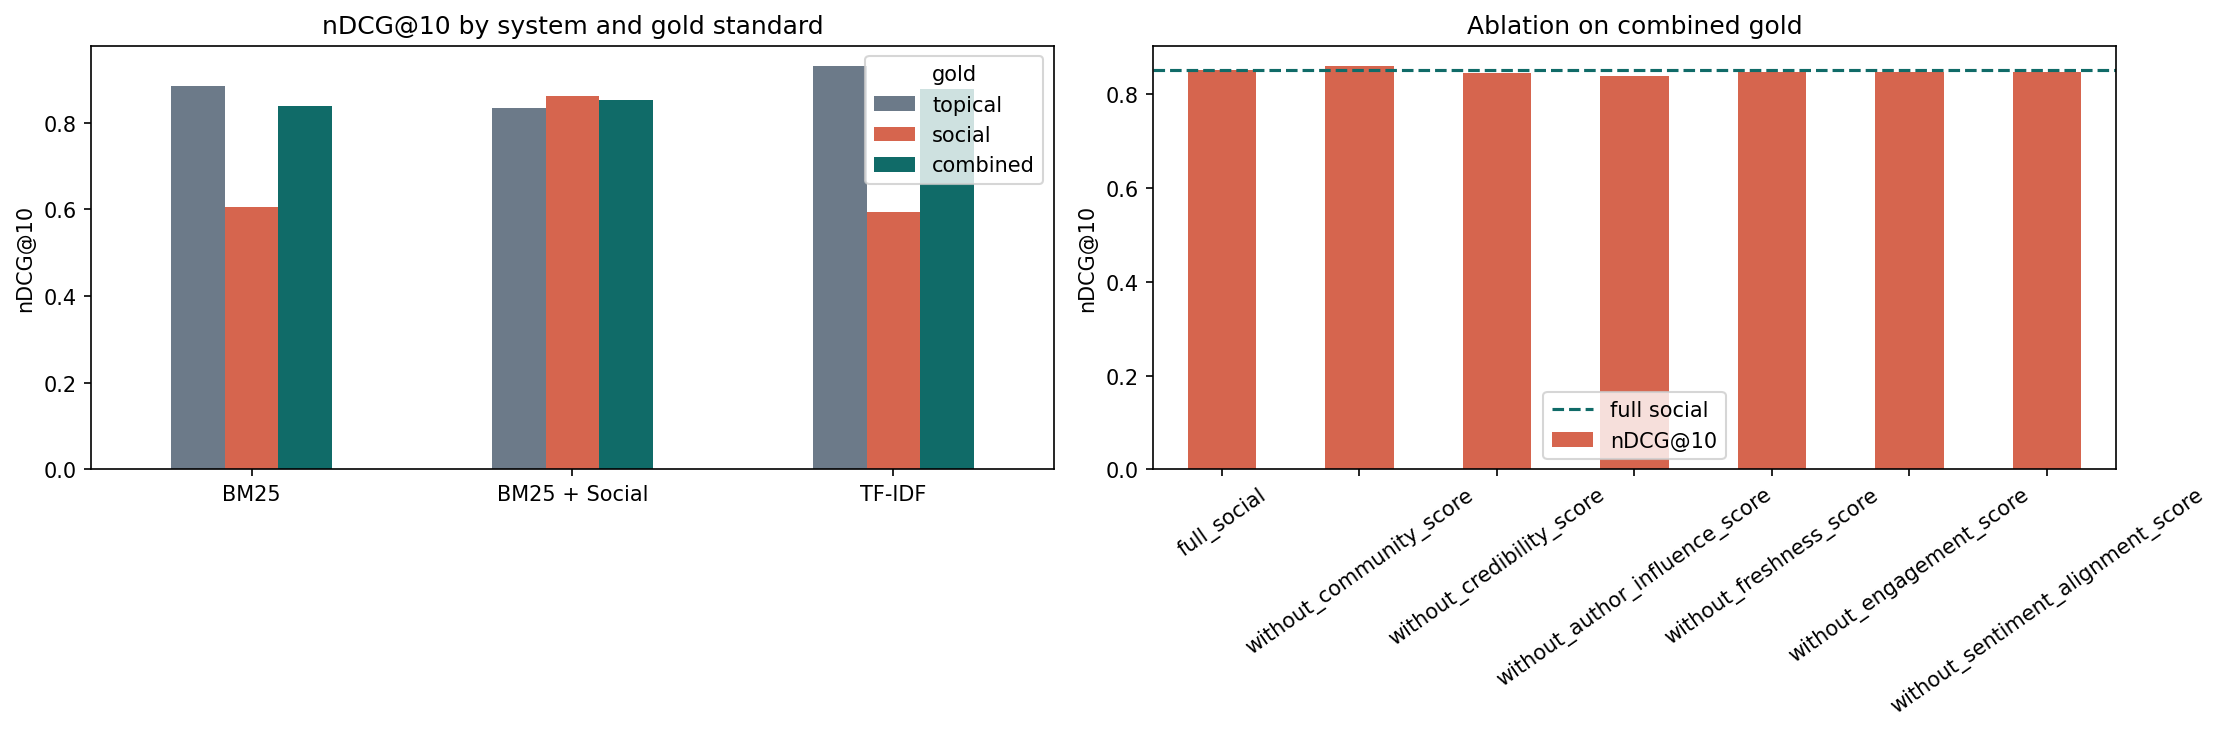

In [14]:
queries = judged[['query_id', 'query']].drop_duplicates()
ablation_rows = []
for ablate in [None, 'community_score', 'credibility_score', 'author_influence_score', 'freshness_score', 'engagement_score', 'sentiment_alignment_score']:
    run = {}
    for _, row in queries.iterrows():
        cand = retrieve_candidates(docs, row['query'], 'bm25', config.DEFAULT_CANDIDATES)
        reranked = apply_social_reranking(cand, row['query'], ablate=ablate, graph_ctx=graph_ctx).head(10)
        run[row['query_id']] = reranked['doc_id'].astype(str).tolist()
    name = 'full_social' if ablate is None else f'without_{ablate}'
    ablation_rows.append(evaluate_run(run, judged, 'combined_gold_0_3', name))
ablation = pd.DataFrame(ablation_rows)
display(ablation[['run', 'Precision@10', 'MAP', 'nDCG@10']].round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
pivot = metrics.pivot(index='run', columns='gold', values='nDCG@10')[['topical', 'social', 'combined']]
pivot.plot(kind='bar', ax=axes[0], color=['#6c7a89', '#d6654e', '#106b68'])
axes[0].set_title('nDCG@10 by system and gold standard')
axes[0].set_ylabel('nDCG@10')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='gold')

ablation.plot(x='run', y='nDCG@10', kind='bar', ax=axes[1], color='#d6654e', legend=False)
full_value = float(ablation.loc[ablation['run'] == 'full_social', 'nDCG@10'].iloc[0])
axes[1].axhline(full_value, color='#106b68', linestyle='--', label='full social')
axes[1].set_title('Ablation on combined gold')
axes[1].set_ylabel('nDCG@10')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend()
show_fig(fig)


## 10. What the notebook demonstrates

- The corpus has both topical text and social evidence, so the retrievable unit is not just a document: it is an answer with author, asker, commenters, reputation, votes, acceptance, tags, and recency.
- BM25 and TF-IDF provide topical candidates.
- Social re-ranking keeps topical relevance as the largest weight, then adds community approval, author credibility, PageRank influence, engagement, freshness, tag overlap, and financial sentiment alignment.
- Searcher profiles activate personalized graph features, so the same query can produce different rankings.
- The evaluation checks topical, social-usefulness, and combined gold labels, plus ablation, all displayed inline.
